Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'entropy', 'bootstrap': False}

Accuracy : 0.75
Precision: 0.6429
Recall   : 0.7864
F1 Score : 0.7074

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       165
           1       0.64      0.79      0.71       103

    accuracy                           0.75       268
   macro avg       0.74      0.76      0.74       268
weighted avg       0.77      0.75      0.75       268



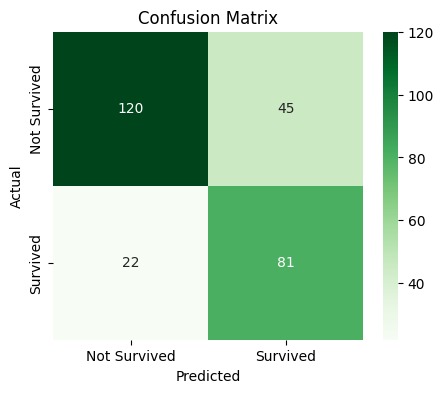

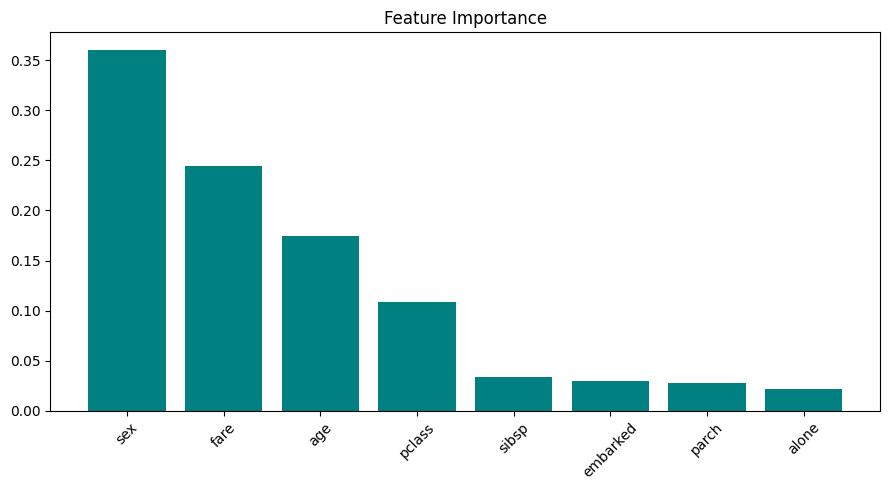

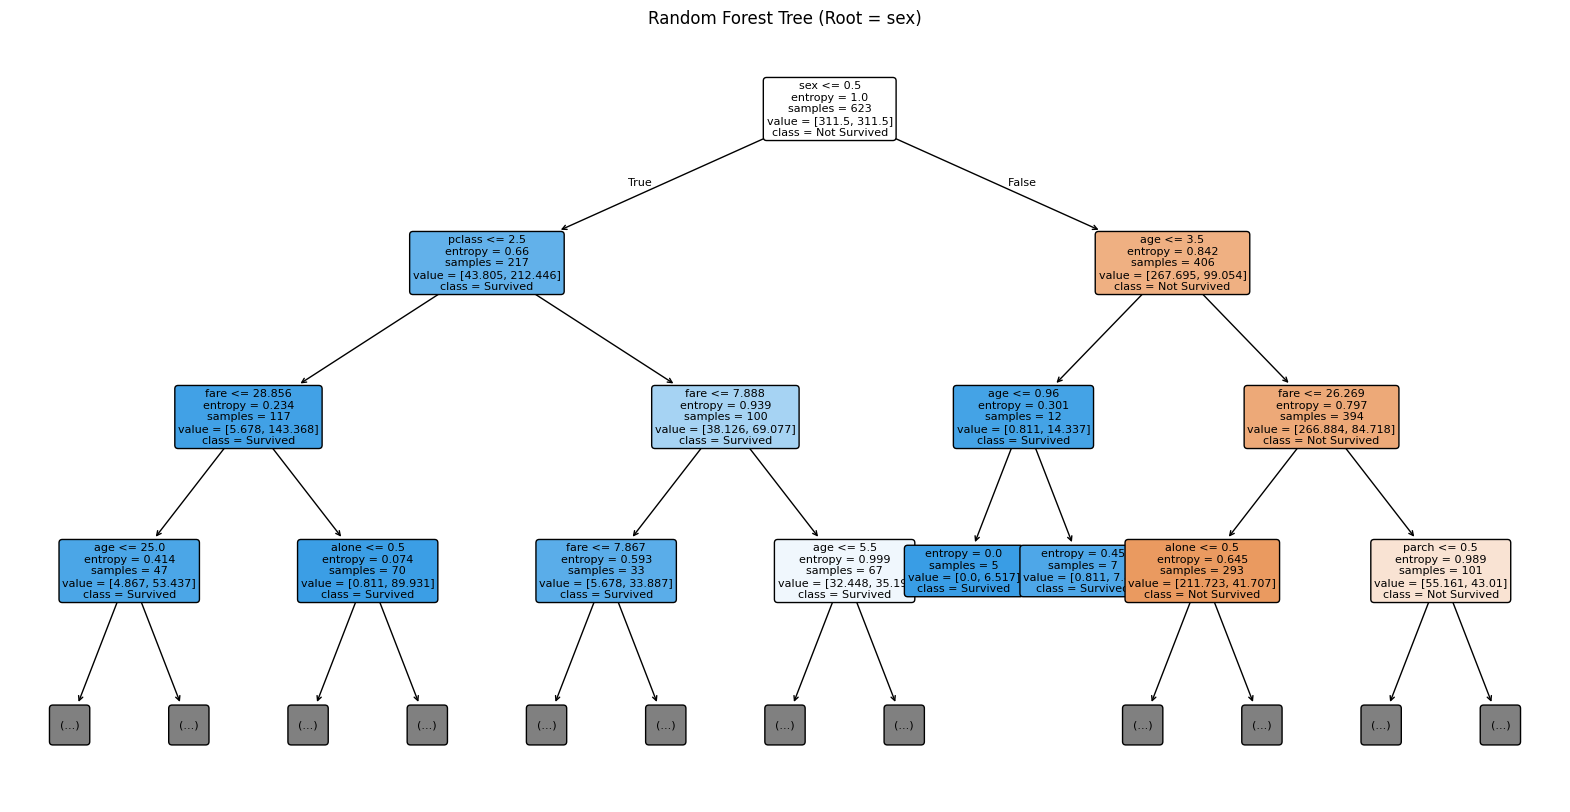

In [6]:
# Titanic Classification with Random Forest (Hyperparameter Tuning for Higher Recall)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import plot_tree

# -----------------------------
# Load Titanic Dataset
# -----------------------------
df = sns.load_dataset("titanic")

# Drop unnecessary columns
df.drop(['deck', 'embark_town', 'alive', 'class', 'who'], axis=1, inplace=True)

# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['alone'].fillna(df['alone'].mode()[0], inplace=True)

# Encode categorical variables
encoder = LabelEncoder()
for col in ['sex', 'embarked', 'alone']:
    df[col] = encoder.fit_transform(df[col])

# Remove highly correlated feature
df.drop('adult_male', axis=1, inplace=True)

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# -----------------------------
# Random Forest
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Hyperparameter Space
param_dist = {
    'n_estimators': [200,300,400,500,700],
    'max_depth': [5,8,10,15,20,None],
    'min_samples_split': [2,4,6,8,10],
    'min_samples_leaf': [1,2,3,4],
    'max_features': ['sqrt','log2',None],
    'bootstrap': [True,False],
    'criterion': ['gini','entropy']
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',      # Optimize Recall
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

rf_best = random_search.best_estimator_

# -----------------------------
# Prediction
# -----------------------------
# Lower threshold for higher recall
y_prob = rf_best.predict_proba(X_test)[:,1]
threshold = 0.40
y_pred = (y_prob >= threshold).astype(int)

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy :", round(accuracy_score(y_test,y_pred),4))
print("Precision:", round(precision_score(y_test,y_pred),4))
print("Recall   :", round(recall_score(y_test,y_pred),4))
print("F1 Score :", round(f1_score(y_test,y_pred),4))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = rf_best.feature_importances_
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(9,5))
plt.bar(range(len(indices)), importance[indices], color='teal')
plt.xticks(range(len(indices)),
           X.columns[indices],
           rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# Visualize One Tree
# -----------------------------
root_feature = indices[0]

tree_idx = next(
    (i for i, est in enumerate(rf_best.estimators_)
     if est.tree_.feature[0] == root_feature),
    0
)

plt.figure(figsize=(20,10))
plot_tree(
    rf_best.estimators_[tree_idx],
    feature_names=X.columns,
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title(f"Random Forest Tree (Root = {X.columns[root_feature]})")
plt.show()

R² Score: 0.8137989132905394
Mean Absolute Error (MAE): 0.33081736408268764
Root Mean Squared Error (RMSE): 0.4943646371097895


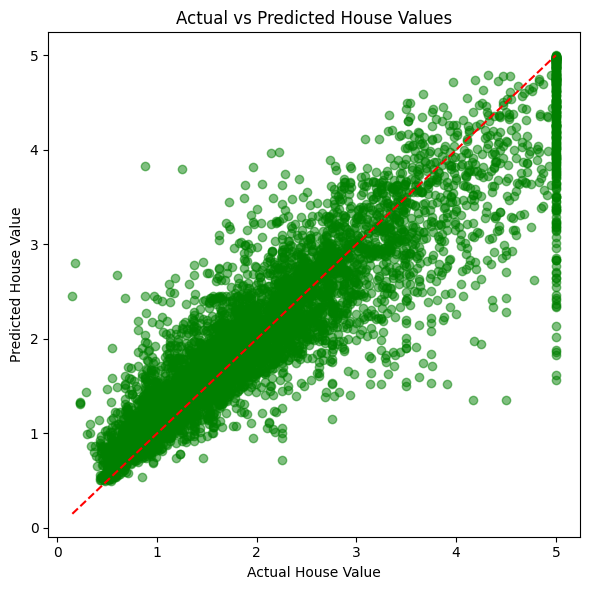

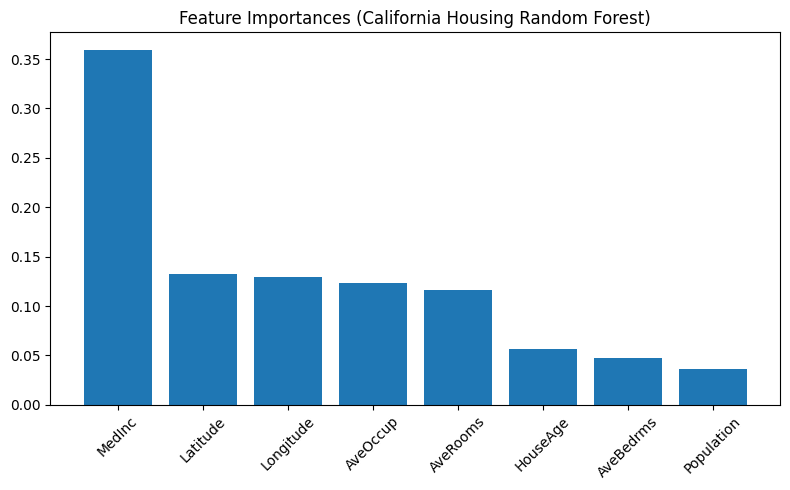

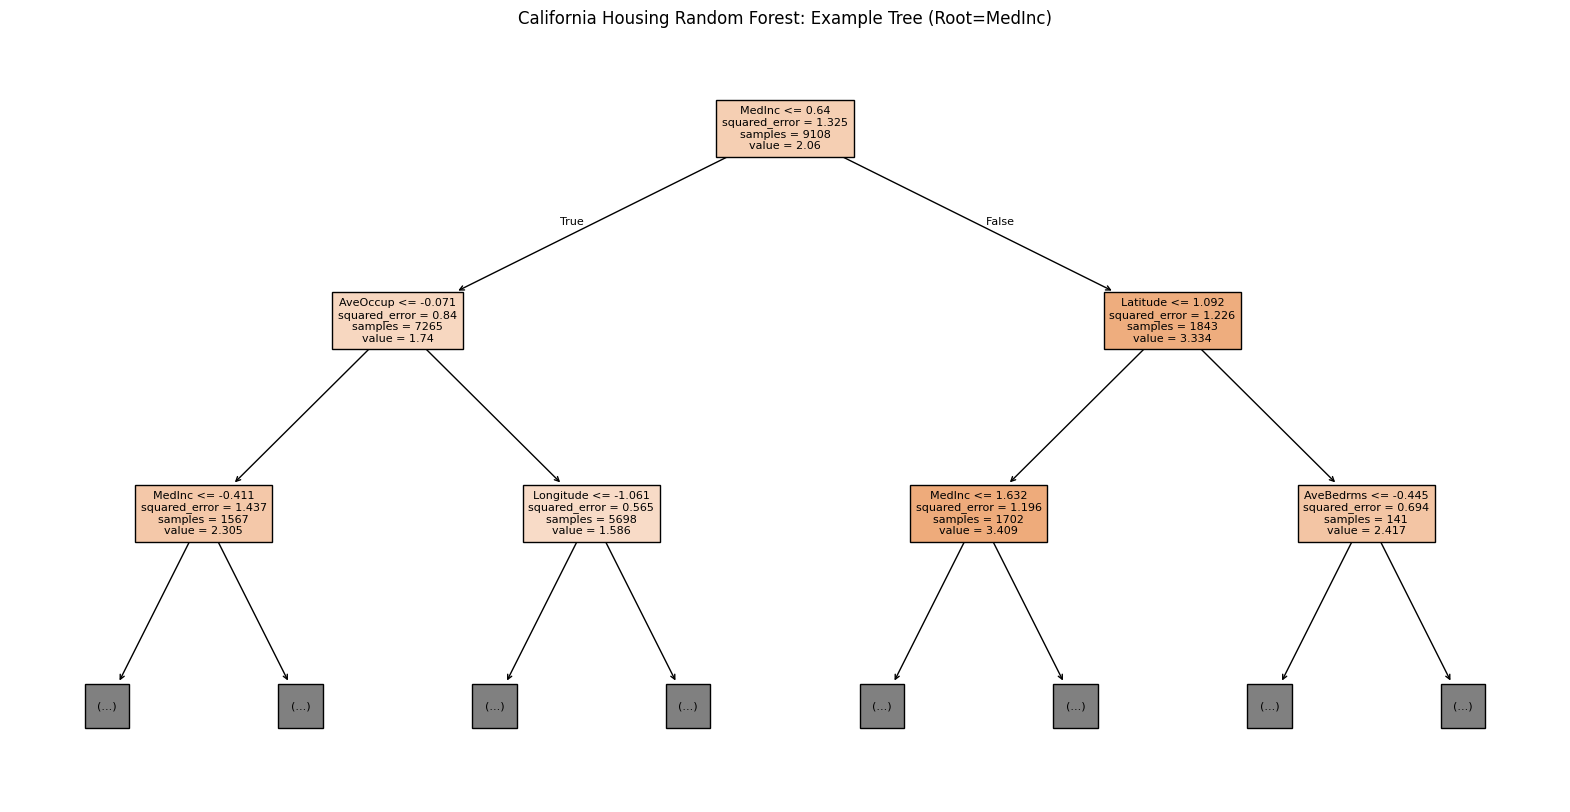